# Uber Rideshare Analysis
**Database:** `rideshare.db`  
**Sections:** Trip Analysis · Payment Analysis · User & Driver Analysis · Data Quality · Advanced Analytics · ML Prediction

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option('display.max_columns', None)

In [2]:
# Update this path to your local rideshare.db location
DB_PATH = r"C:\Users\DELL\Downloads\uber\rideshare.db"
conn = sqlite3.connect(DB_PATH)
print("Connected successfully")

Connected successfully


In [3]:
# List all tables
tables_df = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'", conn
)
print("Tables:", tables_df['name'].tolist())

Tables: ['users', 'drivers', 'riders', 'locations', 'trips', 'payments', 'reviews', 'cancellations']


## 2. Trip Analysis

In [4]:
# Total trips in the dataset
df_total_trips = pd.read_sql_query(
    "SELECT COUNT(trip_id) AS Total_Trips FROM trips", conn
)
df_total_trips

,Total_Trips
0,20000


                 Count
Completed_Trips  16827
Cancelled_Trips   2966


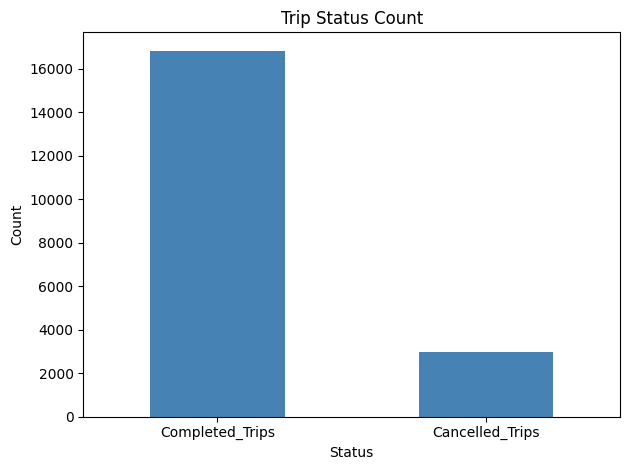

In [5]:
# Completed vs Cancelled trips
query = """
SELECT
    COUNT(CASE WHEN status = 'completed' THEN 1 END) AS Completed_Trips,
    COUNT(CASE WHEN status = 'cancelled' THEN 1 END) AS Cancelled_Trips
FROM trips
"""
df_trip_status = pd.read_sql_query(query, conn).T
df_trip_status.columns = ['Count']
print(df_trip_status)

df_trip_status.plot(kind='bar', legend=False, color=['steelblue', 'tomato'])
plt.title('Trip Status Count')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

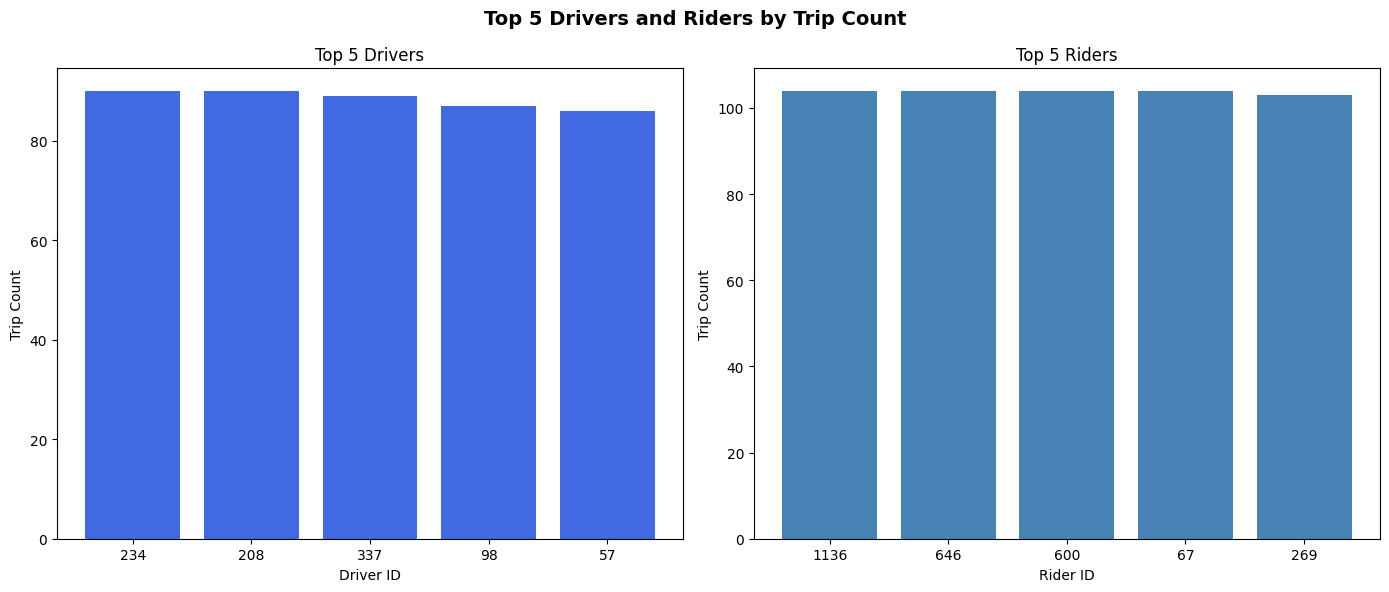

   driver_id  Total_Trips
0        234           90
1        208           90
2        337           89
3         98           87
4         57           86
   rider_id  Trip_Count
0      1136         104
1       646         104
2       600         104
3        67         104
4       269         103


In [6]:
# Top 5 drivers and riders by trip count
df_driver_trips = pd.read_sql_query("""
    SELECT driver_id, COUNT(trip_id) AS Total_Trips
    FROM trips
    GROUP BY driver_id
    ORDER BY Total_Trips DESC
    LIMIT 5
""", conn)

df_rider_trips = pd.read_sql_query("""
    SELECT rider_id, COUNT(trip_id) AS Trip_Count
    FROM trips
    GROUP BY rider_id
    ORDER BY Trip_Count DESC
    LIMIT 5
""", conn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Top 5 Drivers and Riders by Trip Count', fontsize=14, fontweight='bold')

ax1.bar(df_driver_trips['driver_id'].astype(str), df_driver_trips['Total_Trips'], color='royalblue')
ax1.set_title('Top 5 Drivers')
ax1.set_xlabel('Driver ID')
ax1.set_ylabel('Trip Count')

ax2.bar(df_rider_trips['rider_id'].astype(str), df_rider_trips['Trip_Count'], color='steelblue')
ax2.set_title('Top 5 Riders')
ax2.set_xlabel('Rider ID')
ax2.set_ylabel('Trip Count')

plt.tight_layout()
plt.show()
print(df_driver_trips)
print(df_rider_trips)

In [7]:
# Average trip duration (minutes)
df_avg_duration = pd.read_sql_query("""
    SELECT ROUND(AVG(duration_mins), 2) AS Avg_Duration_Minutes
    FROM trips
""", conn)
df_avg_duration

,Avg_Duration_Minutes
0,31.32


In [8]:
# Peak hour — which hour has the most trips booked
df_peak_hours = pd.read_sql_query("""
    SELECT
        strftime('%H', requested_at) AS Peak_Hour,
        COUNT(trip_id) AS Trips_Booked
    FROM trips
    GROUP BY Peak_Hour
    ORDER BY Trips_Booked DESC
    LIMIT 1
""", conn)
print(df_peak_hours)

  Peak_Hour  Trips_Booked
0        18           891


## 3. Payment Analysis

In [9]:
# Total revenue generated
df_total_revenue = pd.read_sql_query("""
    SELECT COUNT(trip_id) AS Trip_Count, SUM(amount) AS Total_Revenue
    FROM payments
""", conn)
print(df_total_revenue)

   Trip_Count  Total_Revenue
0       16827      604589.92


In [10]:
# Average fare per trip (top 5 highest)
df_avg_fare = pd.read_sql_query("""
    SELECT trip_id, AVG(amount) AS Avg_Fare
    FROM payments
    GROUP BY trip_id
    ORDER BY Avg_Fare DESC
    LIMIT 5
""", conn)
print(df_avg_fare)

   trip_id  Avg_Fare
0    19709    224.27
1     5380    222.40
2     8306    220.58
3    13361    216.23
4     4156    213.59


In [11]:
# Payment method breakdown
df_payment_method = pd.read_sql_query("""
    SELECT method, COUNT(method) AS Payment_Count
    FROM payments
    GROUP BY method
    ORDER BY Payment_Count DESC
""", conn)
print(df_payment_method)

   method  Payment_Count
0    card           5700
1  wallet           5621
2    cash           5506


In [12]:
# Highest single fare ever charged
df_highest_fare = pd.read_sql_query("""
    SELECT trip_id, amount
    FROM payments
    ORDER BY amount DESC
    LIMIT 1
""", conn)
df_highest_fare

,trip_id,amount
0,19709,224.27


In [13]:
# Trips with revenue above average
df_above_avg = pd.read_sql_query("""
    SELECT
        COUNT(trip_id) AS Trip_Count,
        SUM(amount)    AS Total_Revenue,
        AVG(amount)    AS Avg_Revenue
    FROM payments
    WHERE amount > (SELECT AVG(amount) FROM payments)
""", conn)
print(df_above_avg)

   Trip_Count  Total_Revenue  Avg_Revenue
0        7101      413522.66    58.234426


In [14]:
# Revenue per day (highest revenue day)
df_day_revenue = pd.read_sql_query("""
    SELECT
        strftime('%d', paid_at) AS Day,
        strftime('%m', paid_at) AS Month,
        SUM(amount)             AS Total_Amount
    FROM payments
    GROUP BY Day, Month
    ORDER BY Total_Amount DESC
    LIMIT 1
""", conn)
df_day_revenue

,Day,Month,Total_Amount
0,04,01,2836.53


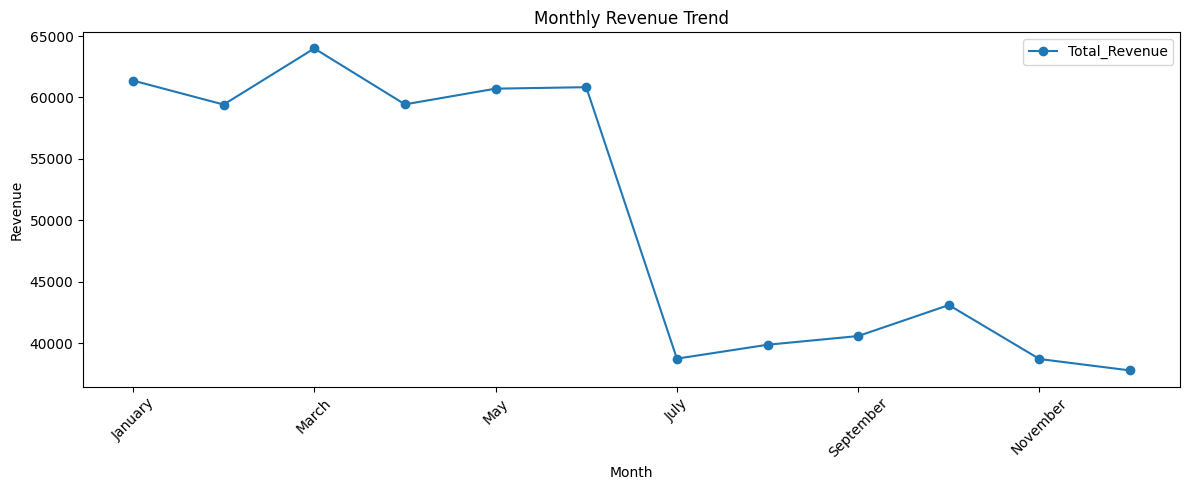

,Month,Total_Revenue
0,January,61378.80
1,February,59423.83
2,March,63993.51
3,April,59441.55
4,May,60720.08
5,June,60838.26
6,July,38742.39
7,August,39873.26
8,September,40582.29
9,October,43103.29


In [15]:
# Monthly revenue trend
df_monthly = pd.read_sql_query("""
    SELECT strftime('%m', paid_at) AS Month, SUM(amount) AS Total_Revenue
    FROM payments
    GROUP BY Month
    ORDER BY Month
""", conn)
df_monthly['Month'] = pd.to_datetime(df_monthly['Month'], format='%m').dt.month_name()

df_monthly.plot(x='Month', y='Total_Revenue', kind='line', marker='o', figsize=(12, 5))
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
df_monthly

In [16]:
# Month-over-month revenue growth
df_mom = pd.read_sql_query("""
    SELECT
        strftime('%Y-%m', paid_at) AS Month,
        ROUND(SUM(amount), 2)      AS Revenue,
        ROUND(
            SUM(amount) - LAG(SUM(amount)) OVER (ORDER BY strftime('%Y-%m', paid_at)),
        2) AS MoM_Growth
    FROM payments
    GROUP BY Month
    ORDER BY Month
""", conn)
df_mom.tail(10)

,Month,Revenue,MoM_Growth
20,2023-09,20898.47,2316.66
21,2023-10,21187.17,288.70
22,2023-11,21143.20,-43.97
23,2023-12,18996.35,-2146.85
24,2024-01,21547.74,2551.39
25,2024-02,20522.30,-1025.44
26,2024-03,21216.04,693.74
27,2024-04,19035.59,-2180.45
28,2024-05,19529.39,493.80
29,2024-06,19587.89,58.50


In [17]:
# Running total of revenue over time
df_running = pd.read_sql_query("""
    SELECT paid_at, amount,
           SUM(amount) OVER (
               ORDER BY paid_at
               ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
           ) AS Running_Revenue
    FROM payments
""", conn)
df_running

,paid_at,amount,Running_Revenue
0,2022-01-01 01:00:54,67.86,67.86
1,2022-01-01 01:32:18,26.76,94.62
2,2022-01-01 02:09:32,45.50,140.12
3,2022-01-01 04:19:03,31.45,171.57
4,2022-01-01 04:51:50,15.29,186.86
...,...,...,...
16822,2024-06-29 15:42:37,29.02,604490.78
16823,2024-06-29 15:44:51,28.71,604519.49
16824,2024-06-29 16:11:57,9.03,604528.52
16825,2024-06-29 22:07:13,47.86,604576.38


## 4. User & Driver Analysis

In [18]:
# Total drivers and riders registered
df_driver_count = pd.read_sql_query(
    "SELECT COUNT(driver_id) AS Drivers_Registered FROM drivers", conn
)
df_rider_count = pd.read_sql_query(
    "SELECT COUNT(user_id) AS Rider_Count FROM users", conn
)
print(df_driver_count)
print(df_rider_count)

   Drivers_Registered
0                 400
   Rider_Count
0         2000


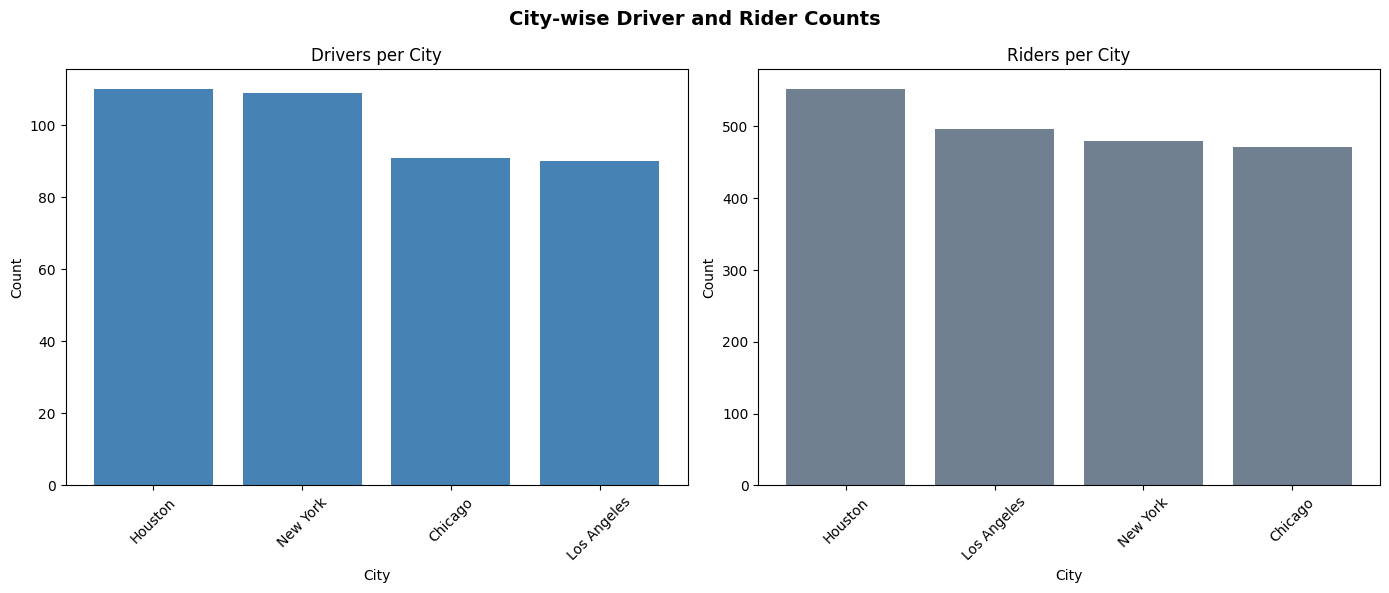

          city  Driver_Count
0      Houston           110
1     New York           109
2      Chicago            91
3  Los Angeles            90
          city  Rider_Count
0      Houston          552
1  Los Angeles          497
2     New York          480
3      Chicago          471


In [19]:
# City-wise driver and rider distribution
df_city_drivers = pd.read_sql_query("""
    SELECT u.city, COUNT(d.driver_id) AS Driver_Count
    FROM drivers d
    JOIN users u ON d.user_id = u.user_id
    GROUP BY u.city
    ORDER BY Driver_Count DESC
""", conn)

df_city_riders = pd.read_sql_query("""
    SELECT city, COUNT(user_id) AS Rider_Count
    FROM users
    GROUP BY city
    ORDER BY Rider_Count DESC
""", conn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('City-wise Driver and Rider Counts', fontsize=14, fontweight='bold')

ax1.bar(df_city_drivers['city'], df_city_drivers['Driver_Count'], color='steelblue')
ax1.set_title('Drivers per City')
ax1.set_xlabel('City')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(df_city_riders['city'], df_city_riders['Rider_Count'], color='slategrey')
ax2.set_title('Riders per City')
ax2.set_xlabel('City')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print(df_city_drivers)
print(df_city_riders)

In [20]:
# Average driver rating
df_avg_rating = pd.read_sql_query("""
    SELECT ROUND(AVG(rating), 2) AS Avg_Rating FROM drivers
""", conn)
df_avg_rating

,Avg_Rating
0,4.15


In [21]:
# Drivers with rating above 4, grouped by city
df_high_rating = pd.read_sql_query("""
    SELECT u.city, d.driver_id, d.rating
    FROM drivers d
    JOIN users u ON d.user_id = u.user_id
    WHERE d.rating > 4
    GROUP BY u.city
    ORDER BY d.rating DESC
    LIMIT 10
""", conn)
df_high_rating

,city,driver_id,rating
0,Chicago,9,4.98
1,Houston,4,4.82
2,New York,11,4.18
3,Los Angeles,1,4.10


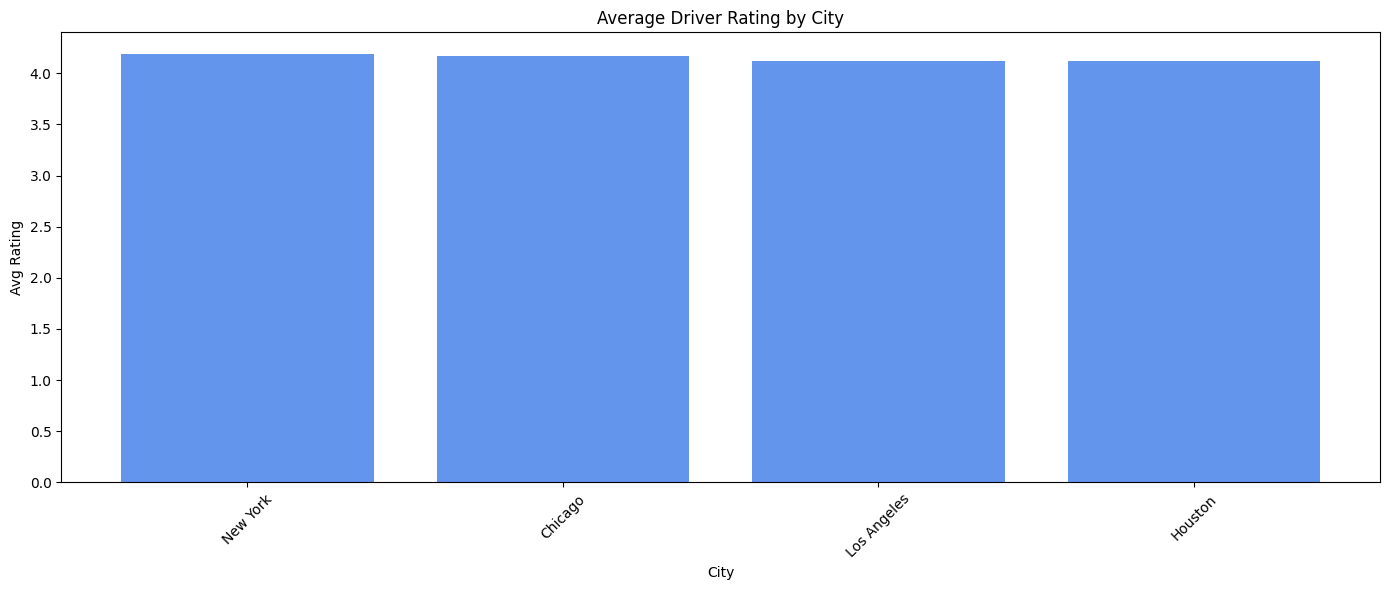

,city,Avg_Rating
0,New York,4.19
1,Chicago,4.17
2,Los Angeles,4.12
3,Houston,4.12


In [22]:
# Average driver rating by city
df_city_rating = pd.read_sql_query("""
    SELECT u.city, ROUND(AVG(d.rating), 2) AS Avg_Rating
    FROM drivers d
    JOIN users u ON d.user_id = u.user_id
    GROUP BY u.city
    ORDER BY Avg_Rating DESC
""", conn)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(df_city_rating['city'], df_city_rating['Avg_Rating'], color='cornflowerblue')
ax.set_title('Average Driver Rating by City')
ax.set_xlabel('City')
ax.set_ylabel('Avg Rating')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
df_city_rating

In [23]:
# Top 10 drivers by total rating score
df_driver_rating = pd.read_sql_query("""
    SELECT driver_id, SUM(rating) AS Total_Rating
    FROM drivers
    GROUP BY driver_id
    ORDER BY Total_Rating DESC
    LIMIT 10
""", conn)
print(df_driver_rating)

   driver_id  Total_Rating
0         35          5.00
1        178          5.00
2        207          4.99
3        260          4.99
4        298          4.99
5        326          4.99
6          9          4.98
7        116          4.98
8        227          4.98
9         10          4.97


In [24]:
# Drivers with perfect 5.0 rating
df_best_drivers = pd.read_sql_query("""
    SELECT driver_id, rating FROM drivers WHERE rating = 5.0
""", conn)
df_best_drivers

,driver_id,rating
0,35,5.0
1,178,5.0


In [25]:
# Inactive drivers at risk of churning
df_inactive = pd.read_sql_query("""
    SELECT driver_id, join_date, SUM(rating) AS Rating_Count
    FROM drivers
    WHERE is_active = 0
    GROUP BY driver_id, join_date
    ORDER BY Rating_Count DESC
""", conn)
df_inactive

,driver_id,join_date,Rating_Count
0,119,2022-01-31,4.08
1,264,2020-08-01,4.05
2,376,2023-01-06,4.03
3,309,2021-06-08,4.02
4,192,2020-03-29,3.99
5,194,2020-10-29,3.95
6,60,2020-07-16,3.94
7,109,2020-09-04,3.93
8,235,2023-12-30,3.93
9,161,2023-03-31,3.92


In [26]:
# Rank drivers by total earnings
df_driver_ranked = pd.read_sql_query("""
    SELECT
        rider_id,
        COUNT(trip_id)          AS Trip_Taken,
        SUM(total_fare)         AS Amount,
        RANK() OVER (ORDER BY SUM(total_fare) DESC) AS Rank
    FROM trips
    GROUP BY rider_id
""", conn)
df_driver_ranked

,rider_id,Trip_Taken,Amount,Rank
0,646,104,3943.55,1
1,1442,102,3909.50,2
2,689,101,3900.65,3
3,158,103,3892.86,4
4,739,99,3864.84,5
...,...,...,...,...
1566,954,1,3.85,1567
1567,1024,1,3.72,1568
1568,284,1,3.69,1569
1569,1165,1,3.65,1570


In [27]:
# Top 3 riders per city by trip count
df_top_riders_city = pd.read_sql_query("""
    SELECT u.city, t.rider_id,
           RANK() OVER (PARTITION BY u.city ORDER BY COUNT(t.trip_id) DESC) AS Rank
    FROM trips t
    JOIN drivers d ON t.driver_id = d.driver_id
    JOIN users u   ON d.user_id   = u.user_id
    GROUP BY u.city, t.rider_id
""", conn)
df_top_riders_city[df_top_riders_city['Rank'] <= 3]

,city,rider_id,Rank
0,Chicago,269,1
1,Chicago,1161,2
2,Chicago,906,3
3,Chicago,833,3
4,Chicago,400,3
5,Chicago,298,3
985,Houston,282,1
986,Houston,646,2
987,Houston,689,3
988,Houston,595,3


In [28]:
# Compare each driver's total fare vs average fare (top 10)
df_fare_compare = pd.read_sql_query("""
    SELECT d.driver_id,
           SUM(t.total_fare)          AS Total_Fare,
           ROUND(AVG(t.total_fare), 2) AS Avg_Fare
    FROM drivers d
    JOIN trips t ON d.driver_id = t.driver_id
    GROUP BY d.driver_id
    ORDER BY Total_Fare DESC
    LIMIT 10
""", conn)
df_fare_compare

,driver_id,Total_Fare,Avg_Fare
0,234,4265.13,47.39
1,10,3889.12,45.75
2,98,3854.21,44.30
3,240,3825.81,45.55
4,34,3818.74,48.34
5,57,3818.35,44.40
6,303,3691.69,49.22
7,337,3643.53,40.94
8,31,3629.35,45.94
9,63,3612.17,51.60


In [29]:
# Cancellation rate per city
df_cancel_rate = pd.read_sql_query("""
    SELECT u.city,
           ROUND(
               COUNT(CASE WHEN t.status = 'cancelled' THEN 1 END) * 100.0
               / COUNT(t.trip_id), 2
           ) AS Cancellation_Rate
    FROM trips t
    JOIN drivers d ON t.driver_id = d.driver_id
    JOIN users u   ON d.user_id   = u.user_id
    GROUP BY u.city
""", conn)
df_cancel_rate

,city,Cancellation_Rate
0,Chicago,14.15
1,Houston,15.58
2,Los Angeles,15.41
3,New York,14.26


## 5. Data Quality & Cleaning

In [30]:
# Check NULL values across all tables
tables = ['users', 'drivers', 'riders', 'locations',
          'trips', 'payments', 'reviews', 'cancellations']

for table in tables:
    df = pd.read_sql_query(f"SELECT * FROM {table}", conn)
    null_counts = df.isnull().sum()
    total_nulls = null_counts.sum()
    print(f"\n--- {table.upper()} (total NULLs: {total_nulls}) ---")
    print(null_counts[null_counts > 0] if total_nulls > 0 else "No NULLs")


--- USERS (total NULLs: 0) ---
No NULLs

--- DRIVERS (total NULLs: 0) ---
No NULLs

--- RIDERS (total NULLs: 0) ---
No NULLs

--- LOCATIONS (total NULLs: 0) ---
No NULLs

--- TRIPS (total NULLs: 3173) ---
completed_at    3173
dtype: int64

--- PAYMENTS (total NULLs: 0) ---
No NULLs

--- REVIEWS (total NULLs: 5920) ---
comment    5920
dtype: int64

--- CANCELLATIONS (total NULLs: 0) ---
No NULLs


In [31]:
# Handle NULLs — reviews: fill missing comments
df_reviews_clean = pd.read_sql_query("""
    SELECT review_id, rating,
           COALESCE(comment, 'No_Comment') AS comment
    FROM reviews
""", conn)
df_reviews_clean

,review_id,rating,comment
0,1,4,Very comfortable ride.
1,2,4,Super friendly and helpful.
2,3,4,Very clean car.
3,4,4,No_Comment
4,5,3,No_Comment
...,...,...,...
15131,15132,4,"Quick and efficient, thanks!"
15132,15133,3,No_Comment
15133,15134,5,"Great rider, very polite."
15134,15135,3,Super friendly and helpful.


In [32]:
# Handle NULLs — trips: fill missing completed_at
df_trips_clean = pd.read_sql_query("""
    SELECT trip_id, status,
           COALESCE(completed_at, 'Not Completed') AS completed_at
    FROM trips
""", conn)
df_trips_clean

,trip_id,status,completed_at
0,1,completed,2024-06-24 14:24:11
1,2,cancelled,Not Completed
2,3,completed,2023-08-17 09:36:06
3,4,completed,2022-11-21 10:17:31
4,5,completed,2022-01-15 14:56:56
...,...,...,...
19995,19996,completed,2024-06-05 07:39:15
19996,19997,completed,2022-04-14 07:53:13
19997,19998,completed,2024-03-28 05:12:48
19998,19999,completed,2022-06-22 15:12:28


In [33]:
# Duplicate trip IDs
df_dupes = pd.read_sql_query("""
    SELECT trip_id, COUNT(*) AS Duplicate_Count
    FROM trips
    GROUP BY trip_id
    HAVING COUNT(*) > 1
""", conn)
print(f"Duplicate trip IDs found: {len(df_dupes)}")
df_dupes

Duplicate trip IDs found: 0


,trip_id,Duplicate_Count


In [34]:
# Trips with negative duration
df_neg_duration = pd.read_sql_query("""
    SELECT duration_mins, COUNT(*) AS Count
    FROM trips
    WHERE duration_mins < 0
    GROUP BY duration_mins
""", conn)
print(f"Records with negative duration: {df_neg_duration['Count'].sum() if len(df_neg_duration) else 0}")
df_neg_duration

Records with negative duration: 0


,duration_mins,Count


In [35]:
# Payments with zero amount
df_zero_payments = pd.read_sql_query("""
    SELECT payment_id, amount
    FROM payments
    WHERE amount = 0
""", conn)
print(f"Zero-amount payments: {len(df_zero_payments)}")
df_zero_payments

Zero-amount payments: 0


,payment_id,amount


In [36]:
# Non-completed trips
df_not_completed = pd.read_sql_query("""
    SELECT trip_id, status
    FROM trips
    WHERE status != 'completed'
    GROUP BY trip_id
""", conn)
df_not_completed

,trip_id,status
0,2,cancelled
1,7,cancelled
2,11,in_progress
3,16,cancelled
4,29,cancelled
...,...,...
3168,19963,cancelled
3169,19973,cancelled
3170,19974,cancelled
3171,19990,cancelled


In [37]:
# Detect fare outliers using IQR
df_fares = pd.read_sql_query("SELECT amount FROM payments", conn)
Q1  = df_fares['amount'].quantile(0.25)
Q3  = df_fares['amount'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df_fares[(df_fares['amount'] < lower) | (df_fares['amount'] > upper)]
print(f"Fare outliers found: {len(outliers)}  (below {lower:.2f} or above {upper:.2f})")

Fare outliers found: 845  (below -27.18 or above 88.50)


## 6. Advanced Analytics

In [38]:
# KPI summary
df_kpi = pd.read_sql_query("""
    SELECT
        (SELECT COUNT(*)              FROM trips)   AS Total_Trips,
        (SELECT ROUND(SUM(amount),2)  FROM payments) AS Total_Revenue,
        (SELECT ROUND(AVG(rating),2)  FROM drivers)  AS Avg_Driver_Rating,
        (SELECT ROUND(AVG(rating),2)  FROM riders)   AS Avg_Rider_Rating
""", conn)
df_kpi

,Total_Trips,Total_Revenue,Avg_Driver_Rating,Avg_Rider_Rating
0,20000,604589.92,4.15,3.99


Correlation between rating and fare: 0.0035


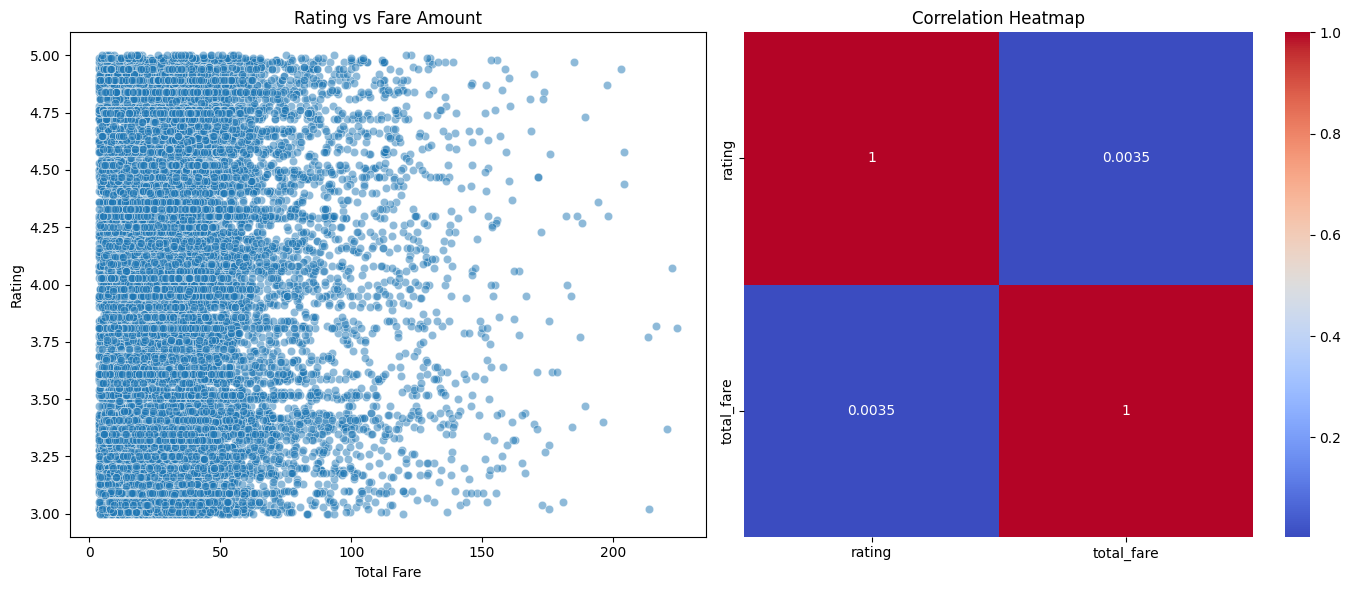

In [39]:
# Correlation between rider rating and fare amount
df_corr = pd.read_sql_query("""
    SELECT r.rating, t.total_fare
    FROM riders r
    JOIN trips t ON r.rider_id = t.rider_id
""", conn)

correlation = df_corr['rating'].corr(df_corr['total_fare'])
print(f"Correlation between rating and fare: {correlation:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=df_corr, x='total_fare', y='rating', alpha=0.5, ax=ax1)
ax1.set_title('Rating vs Fare Amount')
ax1.set_xlabel('Total Fare')
ax1.set_ylabel('Rating')

sns.heatmap(df_corr.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=ax2)
ax2.set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

## 7. ML — Predict Trip Duration

MAE : 8.99 mins
R²  : 0.6275


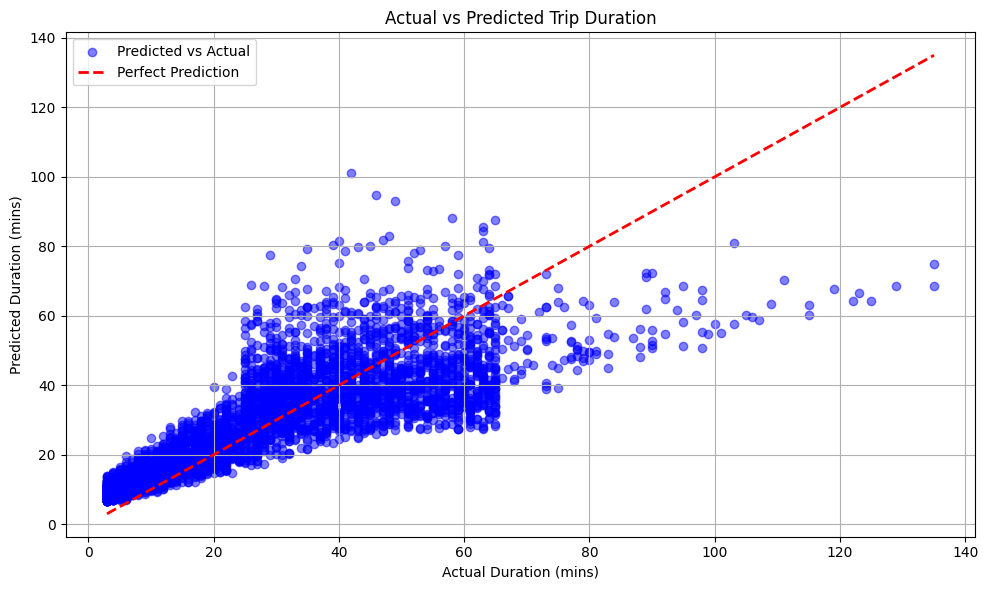

In [40]:
# Linear regression: predict trip duration from fare & distance
df_ml = pd.read_sql_query("""
    SELECT total_fare, distance_km, duration_mins
    FROM trips
    WHERE duration_mins > 0
""", conn).dropna()

X = df_ml[['total_fare', 'distance_km']]
y = df_ml['duration_mins']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f} mins")
print(f"R²  : {r2_score(y_test, y_pred):.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Duration (mins)')
plt.ylabel('Predicted Duration (mins)')
plt.title('Actual vs Predicted Trip Duration')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 8. Export Cleaned Dataset

In [41]:
# Build and export a clean, joined dataset
# Update OUTPUT_PATH as needed
OUTPUT_PATH = r"C:\Users\DELL\Downloads\uber\uber_cleaned.csv"

df_final = pd.read_sql_query("""
    SELECT
        t.trip_id, t.rider_id, t.driver_id, t.status,
        t.distance_km, t.duration_mins, t.total_fare,
        u.name AS rider_name, u.city,
        p.amount, p.method, p.paid_at
    FROM trips t
    JOIN users    u ON t.rider_id = u.user_id
    JOIN payments p ON t.trip_id  = p.trip_id
""", conn).dropna()

df_final.to_csv(OUTPUT_PATH, index=False)
print(f"Exported {len(df_final)} rows to {OUTPUT_PATH}")
df_final.head()

Exported 16827 rows to C:\Users\DELL\Downloads\uber\uber_cleaned.csv


,trip_id,rider_id,driver_id,status,distance_km,duration_mins,total_fare,rider_name,city,amount,method,paid_at
0,1,1,34,completed,39.14,115,68.55,David White,Houston,68.55,wallet,2024-06-24 14:24:15
1,3,2,126,completed,2.78,4,6.36,Justin Young,Houston,6.36,wallet,2023-08-17 09:36:16
2,4,2,255,completed,14.25,19,21.98,Justin Young,Houston,21.98,cash,2022-11-21 10:17:36
3,5,3,186,completed,41.54,44,56.99,Scott Kelly,Los Angeles,56.99,wallet,2022-01-15 14:57:02
4,6,3,370,completed,22.63,40,55.56,Scott Kelly,Los Angeles,55.56,cash,2022-05-05 08:34:02


In [42]:
users = pd.read_sql("SELECT * FROM users", conn)
drivers = pd.read_sql("SELECT * FROM drivers", conn)
riders = pd.read_sql("SELECT * FROM riders", conn)
locations = pd.read_sql("SELECT * FROM locations", conn)
trips = pd.read_sql("SELECT * FROM trips", conn)
payments = pd.read_sql("SELECT * FROM payments", conn)
reviews = pd.read_sql("SELECT * FROM reviews", conn)
cancellations = pd.read_sql("SELECT * FROM cancellations", conn)
users.to_csv('users.csv', index=False)
drivers.to_csv('drivers.csv', index=False)
riders.to_csv('riders.csv', index=False)
locations.to_csv('locations.csv', index=False)
trips.to_csv('trips.csv', index=False)
payments.to_csv('payments.csv', index=False)
reviews.to_csv('reviews.csv', index=False)
cancellations.to_csv('cancellations.csv', index=False)

print("All tables saved as CSV!")

All tables saved as CSV!


In [43]:
conn.close()
print("Database connection closed.")

Database connection closed.
